# Real Estate - Clustering

**Objective**: Segment French real estate zones

##

In [1]:
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
import hdbscan
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler

from src.features.build_features import rename_features

In [2]:
BASE_DIR = Path().resolve().parents[0]
file_path = BASE_DIR / "data/processed/dvf_core.parquet"

df = pd.read_parquet(file_path)

In [3]:
df.shape

(379890, 38)

In [4]:
df = rename_features(df)

features = [
    "Valeur fonciere",
    "Surface reelle bati",
    "Nombre pieces principales",
    "prix_m2",
    "longitude",
    "latitude",
    "MED_SL",
    "LOG",
    "NB_EMPLT",
    "EVOL_POP",
    "EVOL_POP_E_S",
    "LEGAL_UNIT",
    "LEGAL_UNIT_NEW",
    "UNIT_LOC",
    "NB_EMPL",
    "ECOLE",
    "COLLEGE",
    "LYCEE",
    "PHARMACIE",
    "MEDECIN",
    "CHOMAGE",
    "SL",
    "PR_MD60"
]

city_df = df[["longitude", "latitude", "Commune"]].dropna().drop_duplicates(subset=["longitude", "latitude"])
cluster_df = df[features].dropna()

## Feature scaling

In [5]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(cluster_df)

## Identify cluster

### Number of cluster - Elbow method

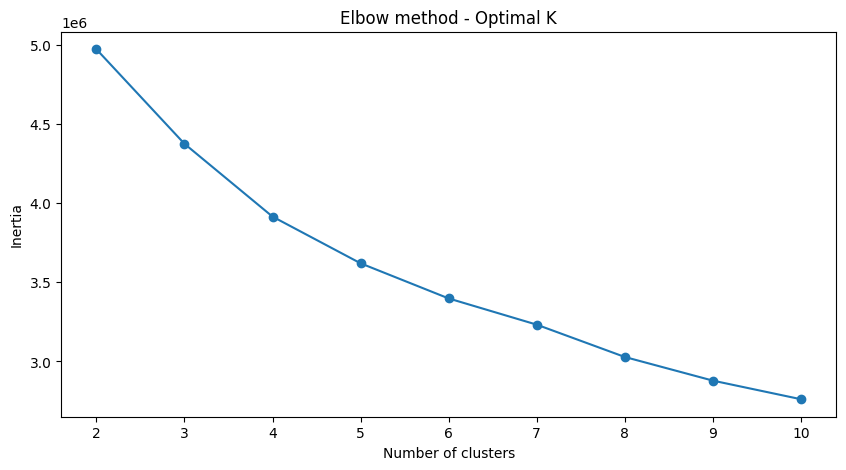

In [6]:
inertia = []

K_range = range(2,11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(10,5))
plt.plot(K_range, inertia, marker="o")
plt.title("Elbow method - Optimal K")
plt.xlabel("Number of clusters")
plt.ylabel("Inertia")
plt.show()

Elbow results :
- K=2 → 5
- K=3 → 4.4
- K=4 → 3.9
- K=5 → 3.6
- K=6 → 3.4
- K=7 → 3.2
- K=8 → 3
- K=9 → 2.8
- K=10 → 2.6

### Number of cluster - Silhouette method

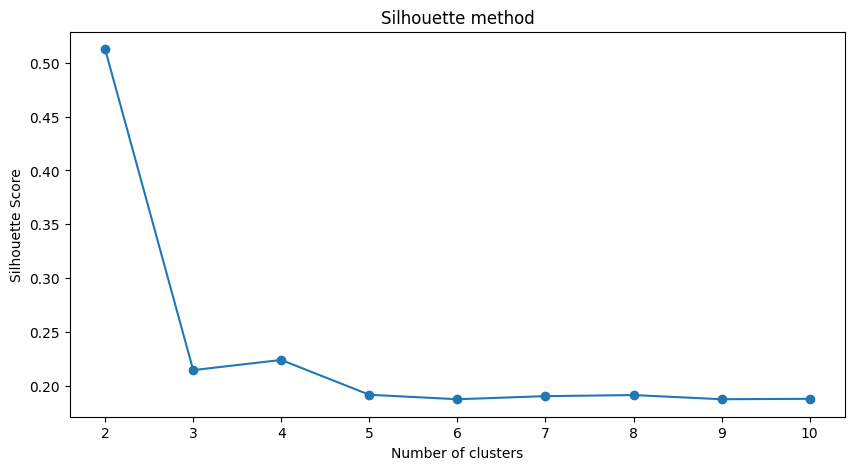

In [7]:
silhouette_scores = []

K_range = range(2,11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_scaled)

    score = silhouette_score(X_scaled, labels, sample_size=5000, random_state=42)
    silhouette_scores.append(score)

plt.figure(figsize=(10,5))
plt.plot(K_range, silhouette_scores, marker="o")
plt.title("Silhouette method")
plt.xlabel("Number of clusters")
plt.ylabel("Silhouette Score")
plt.show()

Silhouette results :
- K=2 → 0.5
- K=3 → 0.22
- K=4 → 0.24
- K=5 → 0.19
- K=6 to K=10 → 0.19

### Conclusion

Failure analysis of KMeans
- Silhouette collapse after K=2
- Unstable cluster quality beyond K=3
- No meaningful elbow

Given the spatial and socio-economic heterogeneity of the dataset, clustering methods assuming spherical and equally dense clusters (such as KMeans) are not appropriate.
Instead, density-based approaches such as HDBSCAN are better suited, as they allow the discovery of arbitrarily shaped clusters and naturally handle varying density regions, which is a key characteristic of real estate markets.

## HDBSCAN - Geographical distribution of clusters

In [8]:
X_geo = cluster_df[["latitude", "longitude"]].values

clusterer = hdbscan.HDBSCAN(
    min_cluster_size=500,
    min_samples=50,
)

labels = clusterer.fit_predict(X_geo)

In [9]:
print(pd.Series(labels).value_counts())

-1      78224
 117     4806
 25      3803
 46      3780
 116     3078
        ...  
 183      523
 59       519
 71       516
 30       507
 27       502
Name: count, Length: 237, dtype: int64


In [10]:
pd.Series(labels).value_counts().describe()

count      237.000000
mean      1417.054852
std       5053.247398
min        502.000000
25%        622.000000
50%        904.000000
75%       1248.000000
max      78224.000000
Name: count, dtype: float64

**Number of cluster**: 237 distinct dense real estate zones

Outliers (-1): equivalent to atypical or transitional areas (mixed areas, blurred peripheries, territories without a strong structure or "intermediate" data)



#### Visualisation

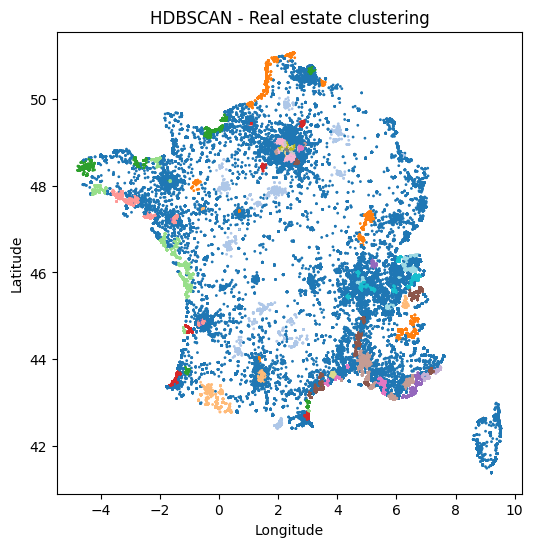

In [11]:
plt.figure(figsize=(6,6))
plt.scatter(
    cluster_df["longitude"],
    cluster_df["latitude"],
    c=labels,
    s=1,
    cmap="tab20"
)
plt.title("HDBSCAN - Real estate clustering")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.show()

#### Visualisation - Without outliers

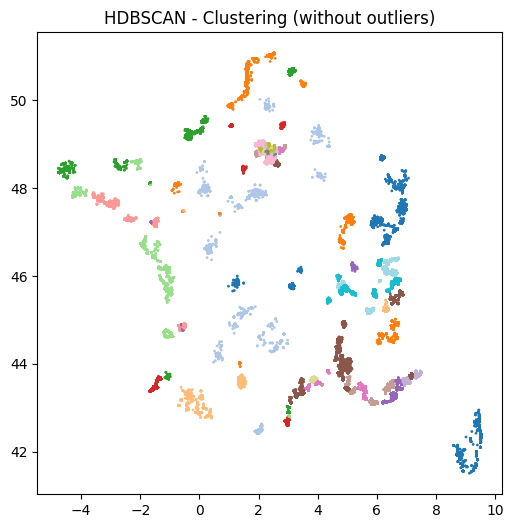

In [12]:
mask = (labels != -1)

plt.figure(figsize=(6,6))
plt.scatter(
    cluster_df.loc[mask, "longitude"],
    cluster_df.loc[mask, "latitude"],
    c=labels[mask],
    s=1,
    cmap="tab20"
)
plt.title("HDBSCAN - Clustering (without outliers)")
plt.show()

By removing noise points (-1), the visualization highlights only dense spatial clusters corresponding to coherent real estate submarkets. These clusters represent localized and structurally similar housing markets, while noise points correspond to transitional or low-density areas.

## Socio-economic analysis of cluster

Characterize each cluster by its averages.

In [13]:
cluster_df = cluster_df.copy()

cluster_df["cluster"] = labels

cluster_core = cluster_df[cluster_df["cluster"] != -1]

In [14]:
cluster_profile = (
    cluster_core.groupby("cluster")[
        ["prix_m2",
        "MED_SL",
        "LOG",
        "NB_EMPLT",
        "LEGAL_UNIT",
        "LEGAL_UNIT_NEW",
        "UNIT_LOC",
        "NB_EMPL",
        "ECOLE",
        "COLLEGE",
        "LYCEE",
        "PHARMACIE",
        "MEDECIN",
        "CHOMAGE",
        "SL",
        "PR_MD60"]
    ].mean(numeric_only=True)
    .round(2)
)

### Map visualisations

#### Map visualisations - Median price/m²

In [15]:
cluster_median_price = (
    cluster_core.groupby("cluster")["prix_m2"]
    .median()
)

cluster_df["cluster_prix"] = cluster_df["cluster"].map(cluster_median_price)

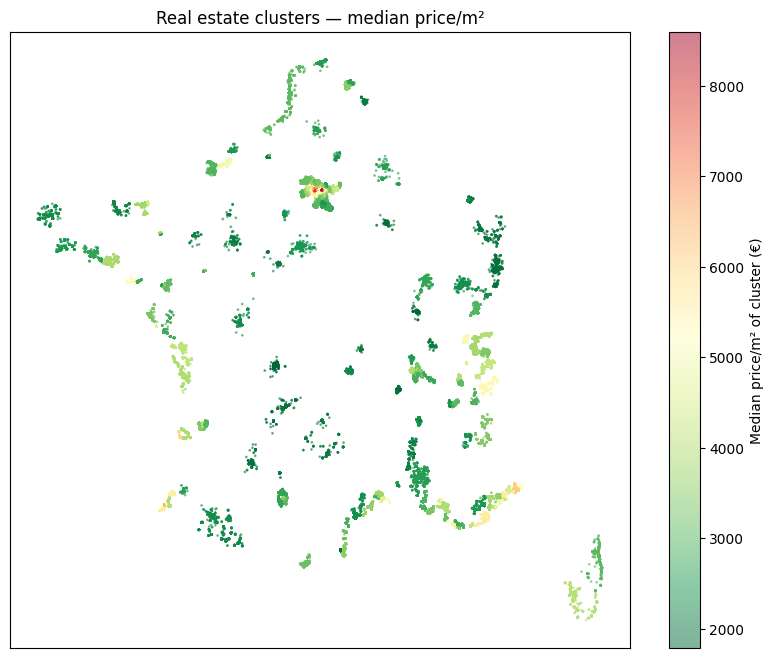

In [48]:
plt.figure(figsize=(10, 8))

scatter = plt.scatter(
    cluster_df["longitude"],
    cluster_df["latitude"],
    c=cluster_df["cluster_prix"],
    cmap="RdYlGn_r",
    s=1,
    alpha=0.5,
)

plt.colorbar(scatter, label="Median price/m² of cluster (€)")
plt.title("Real estate clusters — median price/m²")
plt.xticks([])
plt.yticks([])

plt.show()

Observations :
- Big cities can be distinguish with a warmer cluster colour (Paris, Bordeaux, ...).
- Except clusters at the bottom right (Monaco) and bottom left of France (continental) (Bayonne/Capbreton)

#### Map visualisations - Median rate of unemployment

In [17]:
cluster_median_unemployment = (
    cluster_core.groupby("cluster")["CHOMAGE"]
    .median()
)

cluster_df["cluster_unemployment"] = cluster_df["cluster"].map(cluster_median_unemployment)

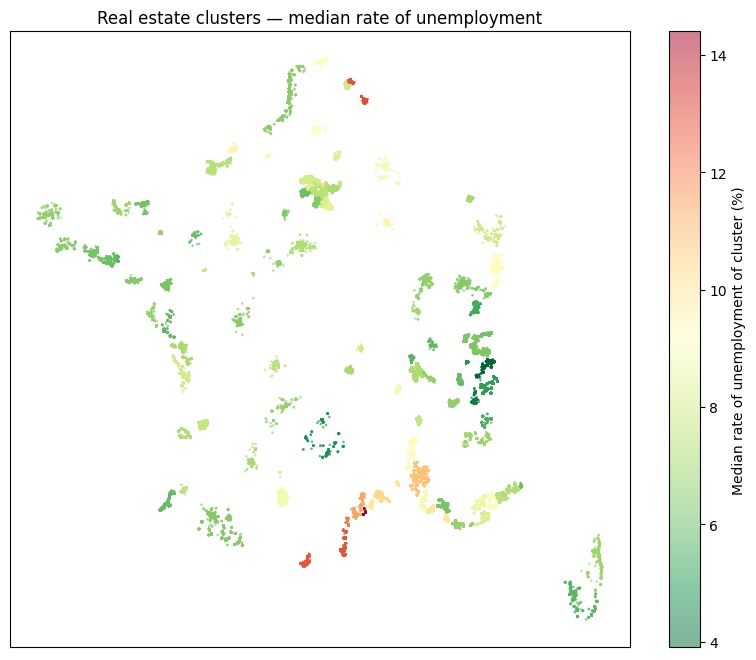

In [18]:
plt.figure(figsize=(10, 8))

scatter = plt.scatter(
    cluster_df["longitude"],
    cluster_df["latitude"],
    c=cluster_df["cluster_unemployment"],
    cmap="RdYlGn_r",
    s=1,
    alpha=0.5,
)

plt.colorbar(scatter, label="Median rate of unemployment of cluster (%)")
plt.title("Real estate clusters — median rate of unemployment")
plt.xticks([])
plt.yticks([])
plt.show()

#### Map visualisations - Median standard of living

In [19]:
cluster_median_med_sl = (
    cluster_core.groupby("cluster")["MED_SL"]
    .median()
)

cluster_df["cluster_med_sl"] = cluster_df["cluster"].map(cluster_median_med_sl)

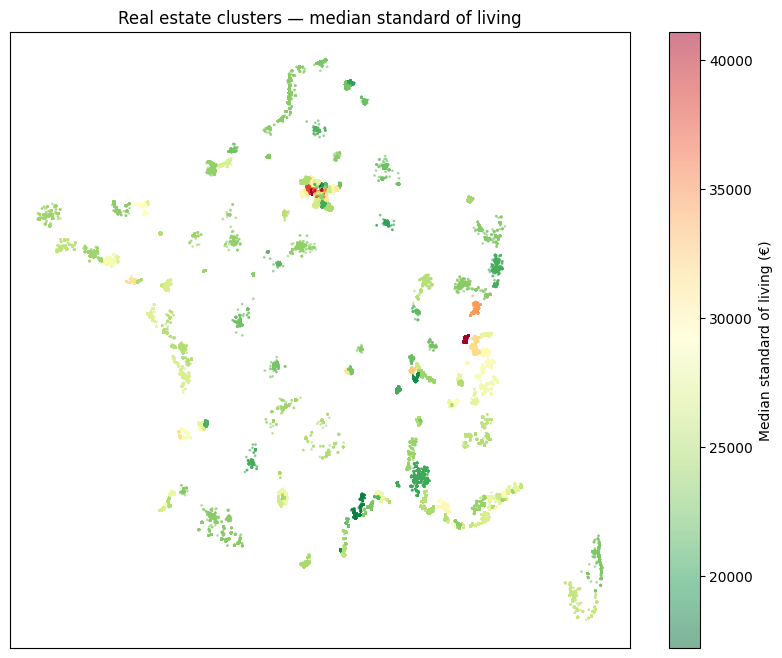

In [20]:
plt.figure(figsize=(10, 8))

scatter = plt.scatter(
    cluster_df["longitude"],
    cluster_df["latitude"],
    c=cluster_df["cluster_med_sl"],
    cmap="RdYlGn_r",
    s=1,
    alpha=0.5,
)

plt.colorbar(scatter, label="Median standard of living (€)")
plt.title("Real estate clusters — median standard of living")
plt.xticks([])
plt.yticks([])
plt.show()

Observations :
- Big cities can be distinguish with a warmer cluster colour (Paris, Nantes, Bordeaux, Lyon, ...).
- Except clusters close to the Switzerland borders

### Cluster profil - Heatmap

#### Top 20 clusters

In [21]:
top_clusters = (
    cluster_core["cluster"]
    .value_counts()
    .head(20)
    .index
)

profile_top = cluster_profile.loc[top_clusters]

profile_normalized = (profile_top - profile_top.mean()) / profile_top.std()

In [22]:
profile_normalized = profile_normalized.astype(float)

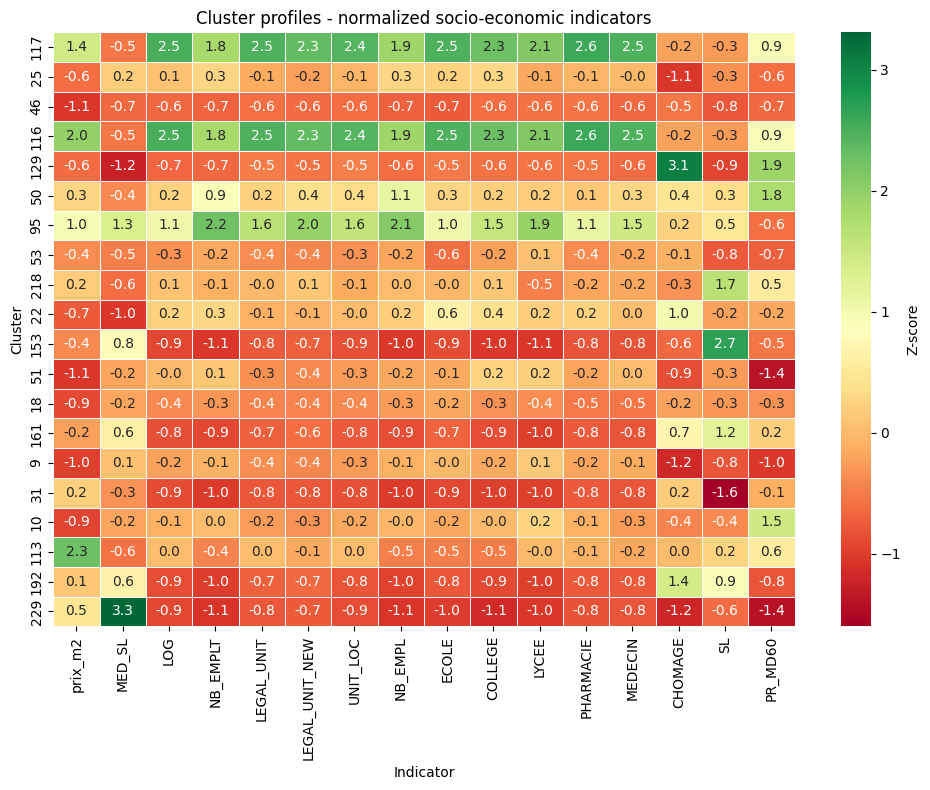

In [23]:
plt.figure(figsize=(10, 8))

sns.heatmap(
    profile_normalized,
    cmap="RdYlGn",
    annot=True,
    fmt=".1f",
    linewidths=0.5,
    cbar_kws={"label": "Z-score"},
)

plt.title("Cluster profiles - normalized socio-economic indicators")
plt.xlabel("Indicator")
plt.ylabel("Cluster")
plt.tight_layout()
plt.show()

Observations :
- Cluster 117, 116 and 95 have most of their soci-economic indicators is green.

### Cluster profil - Naming

In [24]:
def label_cluster(row):

    if (pd.notna(prix_q9) and row["prix_m2"] > prix_q9) or (pd.notna(med_sl_q9) and row["MED_SL"] > med_sl_q9) or (pd.notna(sl_q9) and row["SL"] > sl_q9):
        return "Exceptions"

    elif pd.notna(sum_q9) and row.sum() > sum_q9:
        return "Premium"

    elif (row["prix_m2"] > 0 and row["CHOMAGE"] < 0) or (row["PR_MD60"] < 0 and (row["MED_SL"] > 2 or row["SL"] > 2)):
        return "Affluent Urban"

    elif row["prix_m2"] < 0 and row["CHOMAGE"] > 1:
        return "Economically Fragile"

    elif row["prix_m2"] < 0 and (row["PR_MD60"] > 1 or row["CHOMAGE"] > 1 or row["MED_SL"] < 0):
        return "Deprived Areas"

    elif row["LOG"] < 0 and row["MEDECIN"] < 0 and row["ECOLE"] < 0 and row["COLLEGE"] < 0 and row["LYCEE"] < 0 and row["PHARMACIE"] < 0:
        return "Countryside"

    else:
        return "Intermediate Areas"

#### Top 20 clusters

**Exploratory naming** (superseded by All clusters below)

The following labeling was applied to the top 20 clusters only as a first pass.

The full labeling using all 237 clusters is presented in the next section.

In [25]:
prix_q9 = profile_normalized["prix_m2"].quantile(0.9)
med_sl_q9 = profile_normalized["MED_SL"].quantile(0.9)
sl_q9 = profile_normalized["SL"].quantile(0.9)
sum_q9 = profile_normalized.sum(axis="columns").quantile(0.9)

cluster_df["cluster_name"] = profile_normalized.apply(label_cluster, axis=1)
cluster_df["cluster_name"] = cluster_df["cluster_name"].fillna("Other")

# Distribution
cluster_df["cluster_name"].value_counts()

cluster_name
Other                   335822
Exceptions                   6
Deprived Areas               5
Intermediate Areas           3
Countryside                  3
Economically Fragile         2
Premium                      1
Name: count, dtype: int64

#### All clusters

In [26]:
cluster_profile_all = (
    cluster_core.groupby("cluster")[
        ["prix_m2", "MED_SL", "SL", "CHOMAGE", "PR_MD60", "LOG", "NB_EMPLT", "MEDECIN", "ECOLE", "COLLEGE", "LYCEE", "PHARMACIE"]
    ].median()
)

profile_normalized_all = (cluster_profile_all - cluster_profile_all.mean()) / cluster_profile_all.std()

prix_q9 = profile_normalized_all["prix_m2"].quantile(0.9)
med_sl_q9 = profile_normalized_all["MED_SL"].quantile(0.9)
sl_q9 = profile_normalized_all["SL"].quantile(0.9)
sum_q9 = profile_normalized_all.sum(axis="columns").quantile(0.9)

cluster_name_map = profile_normalized_all.apply(label_cluster, axis=1)

In [27]:
cluster_df["cluster_name"] = (
    cluster_df["cluster"]
    .map(cluster_name_map)
    .fillna("Outliers")
)

cluster_df["cluster_name"].isna().sum()

np.int64(0)

In [28]:
cluster_stats = (
    cluster_df["cluster_name"].value_counts()
    .to_frame("count")
    .assign(proportion=lambda x: (x["count"] / x["count"].sum() * 100).round(2))
)

print(cluster_stats)

                      count  proportion
cluster_name                           
Deprived Areas        90078       26.82
Outliers              78224       23.29
Affluent Urban        45431       13.53
Premium               37572       11.19
Countryside           32093        9.56
Exceptions            29114        8.67
Economically Fragile  22360        6.66
Intermediate Areas      970        0.29


##### Cluster profile - Heatmap

In [29]:
cluster_name_profile = (
    cluster_df[cluster_df["cluster"] != -1]
    .groupby("cluster_name")[
        ["prix_m2", "MED_SL", "SL", "CHOMAGE",
         "PR_MD60", "LOG", "NB_EMPLT", "MEDECIN"]
    ]
    .median()
)

profile_by_name_normalized = (
    (cluster_name_profile - cluster_name_profile.mean())
    / cluster_name_profile.std()
)

profile_by_name_normalized = profile_by_name_normalized.astype("float64")

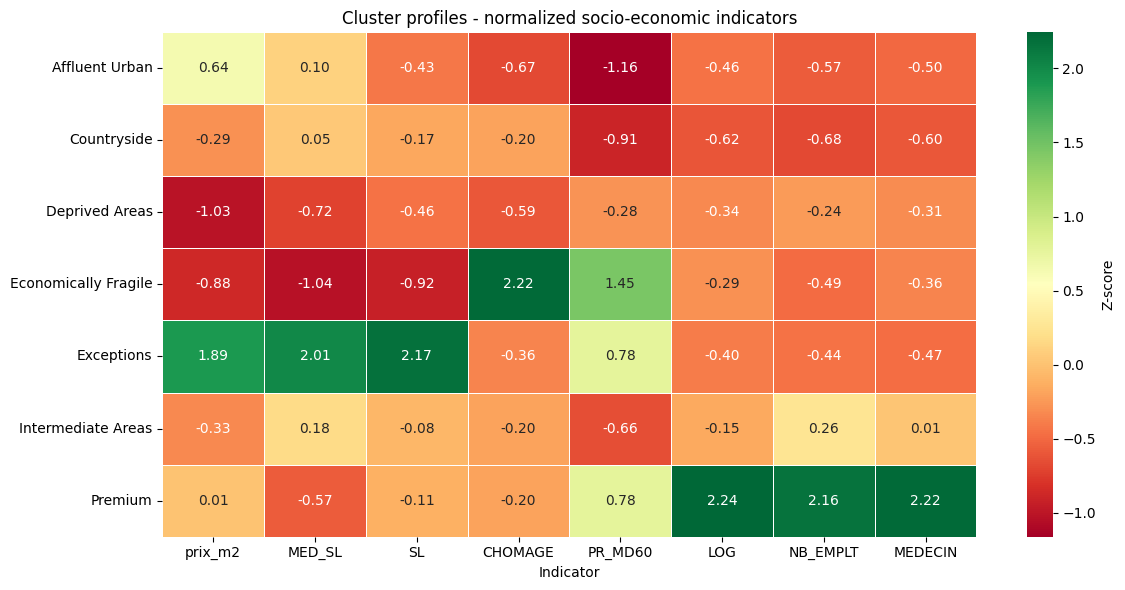

In [50]:
plt.figure(figsize=(12, 6))
sns.heatmap(
    profile_by_name_normalized,
    cmap="RdYlGn",
    annot=True,
    fmt=".2f",
    linewidths=0.5,
    cbar_kws={"label": "Z-score"},
)
plt.title("Cluster profiles - normalized socio-economic indicators")
plt.xlabel("Indicator")
plt.ylabel("")
plt.tight_layout()
plt.show()

Observations :
- Premium and Exceptions cluster have half of their soci-economic indicators is green.
- Countryside and Deprived Areas have most of their indicators in dark orange / red
- Affluent Urban and Intermediate Areas have mostly orange or yellow indicators
- Economically Fragile closter has either red/ dark orange or green (highest unemployment and highest poverty rate) indicators.

## Cluster profil - Visualisation

In [34]:
cluster_order = (
    cluster_df[cluster_df["cluster"] != -1]
    .groupby("cluster_name")["prix_m2"]
    .median()
    .sort_values(ascending=False)
    .index
    .tolist()
)

In [35]:
palette = {
    "Premium"             : "#D84040",   # RED
    "Exceptions"          : "#E8593C",   # ORANGE
    "Affluent Urban"      : "#F2DA23",   # YELLOW
    "Intermediate Areas"  : "#888780",   # GREY
    "Deprived Areas"      : "#3B8BD4",   # BLUE
    "Economically Fragile": "#185FA5",   # DARK BLUE
    "Countryside"         : "#1D9E75",   # GREEN
    "Outliers"            : "#F5F4F2",   # LIGHT GREY
}

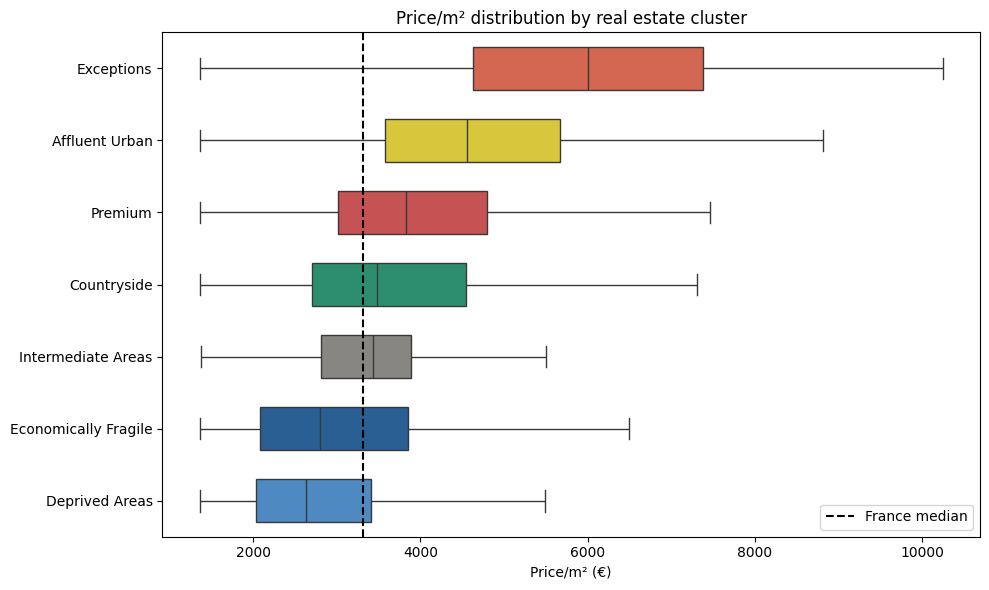

In [51]:
plt.figure(figsize=(10, 6))

sns.boxplot(
    data=cluster_df[cluster_df["cluster"] != -1],
    x="prix_m2",
    y="cluster_name",
    order=cluster_order,
    hue="cluster_name",
    palette=palette,
    legend=False,
    showfliers=False,
    width=0.6,
)

plt.axvline(
    cluster_df["prix_m2"].median(),
    color="black",
    linestyle="dashed",
    label="France median"
)

plt.title("Price/m² distribution by real estate cluster")
plt.xlabel("Price/m² (€)")
plt.ylabel("")
plt.legend()
plt.tight_layout()
plt.show()

### Cluster profil - Price/m² - Reminder

#### Real Estate Prices

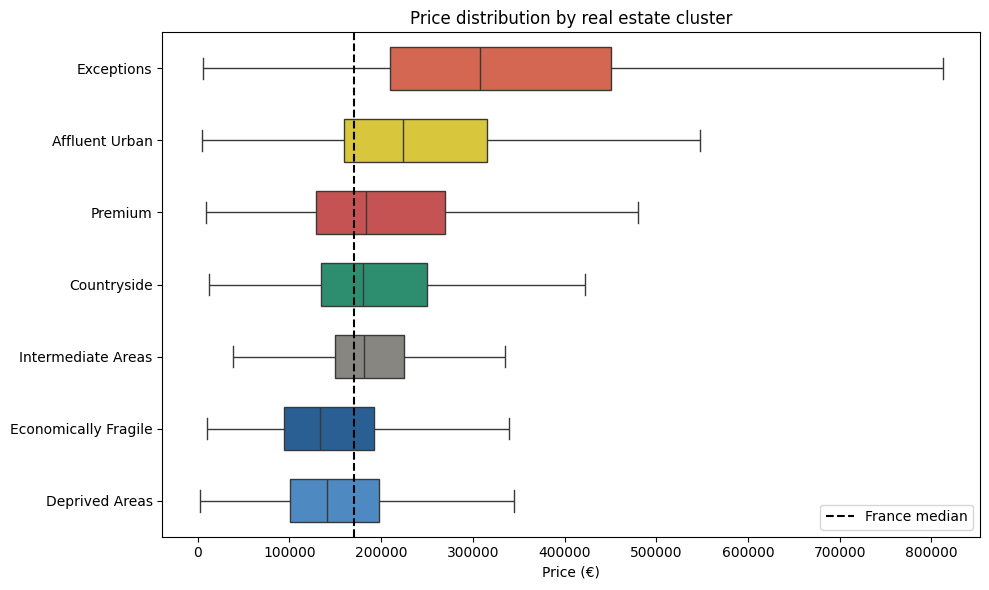

In [37]:
plt.figure(figsize=(10, 6))

sns.boxplot(
    data=cluster_df[cluster_df["cluster"] != -1],
    x="Valeur fonciere",
    y="cluster_name",
    order=cluster_order,
    hue="cluster_name",
    palette=palette,
    legend=False,
    showfliers=False,
    width=0.6,
)

plt.axvline(
    cluster_df["Valeur fonciere"].median(),
    color="black",
    linestyle="dashed",
    label="France median"
)

plt.title("Price distribution by real estate cluster")
plt.xlabel("Price (€)")
plt.ylabel("")
plt.legend()
plt.tight_layout()
plt.show()

France median : 170 000 €

Lower than France median (<) :
- Economically Fragile Areas (~ 130 000 €) (-24%)
- Deprived Areas (~ 140 000 €) (-18%)

Greater than France median (>) :
- Countryside (~ 180 000 €) (+6%)
- Intermediate Areas (~ 180 000 €) (+6%)
- Premium (~ 180 000 €) (+6%)
- Affluent Urban Areas (~ 220 000 €) (+29%)
- Exceptions Areas (~ 310 000 €) (+82%)

#### Surface area

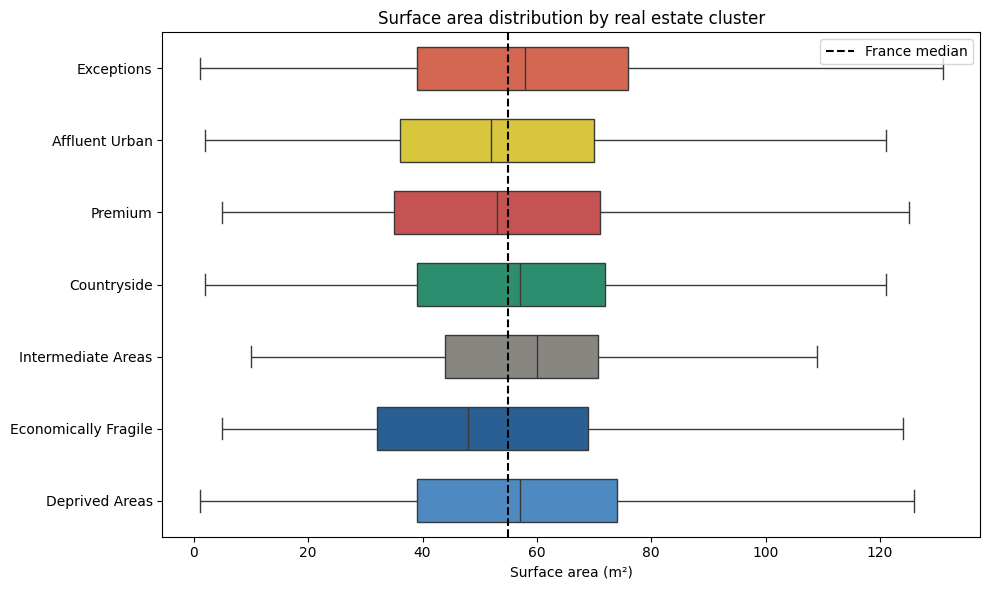

In [38]:
plt.figure(figsize=(10, 6))

sns.boxplot(
    data=cluster_df[cluster_df["cluster"] != -1],
    x="Surface reelle bati",
    y="cluster_name",
    order=cluster_order,
    hue="cluster_name",
    palette=palette,
    legend=False,
    showfliers=False,
    width=0.6,
)

plt.axvline(
    cluster_df["Surface reelle bati"].median(),
    color="black",
    linestyle="dashed",
    label="France median"
)

plt.title("Surface area distribution by real estate cluster")
plt.xlabel("Surface area (m²)")
plt.ylabel("")
plt.legend()
plt.tight_layout()
plt.show()

France median : 55 m²

Lower than France median (<) :
- Economically Fragile Areas (~ 48 m²) (-13%)
- Affluent Urban Areas (~ 52 m²) (-6%)
- Premium (~ 53 m²) (-4%)

Greater than France median (>) :
- Countryside (~ 57 m²) (+3,6%)
- Deprived Areas (~ 57 m²) (+3,6%)
- Exceptions Areas (~ 58 m²) (+6%)
- Intermediate Areas (~ 60 m²) (+9%)

### Cluster profil - Additionnal information

#### Cluster profil - Unemployment rate

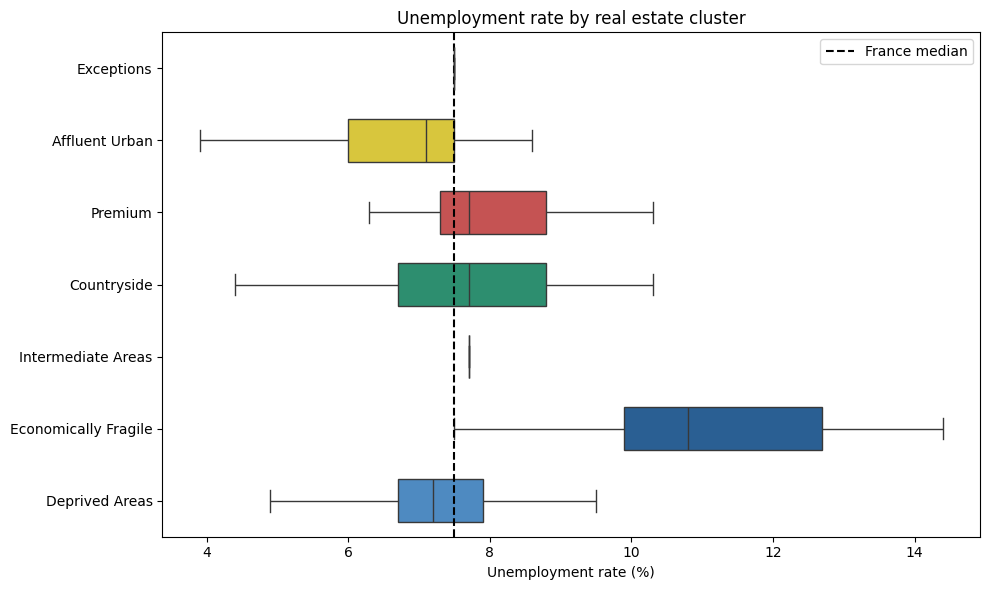

In [39]:
plt.figure(figsize=(10, 6))

sns.boxplot(
    data=cluster_df[cluster_df["cluster"] != -1],
    x="CHOMAGE",
    y="cluster_name",
    order=cluster_order,
    hue="cluster_name",
    palette=palette,
    legend=False,
    showfliers=False,
    width=0.6,
)

plt.axvline(
    cluster_df["CHOMAGE"].median(),
    color="black",
    linestyle="dashed",
    label="France median",
)

plt.title("Unemployment rate by real estate cluster")
plt.xlabel("Unemployment rate (%)")
plt.ylabel("")
plt.legend()
plt.tight_layout()
plt.show()

France median : 7.5 %

Lower than France median (<) :
- Affluent Urban Areas (~ 7,1) (-5%)
- Deprived Areas (~ 7,2) (-4%)
- Outliers (~ 7,3) (-3%)

Greater than France median (>) :
- Countryside (~ 7,7) (+3%)
- Intermediate Areas (~ 7,7) (+3%)
- Premium (~ 7,7) (+3%)
- Economically Fragile Areas (~ 10,8) (+44%)

Exceptions Areas has the same rate as the national one.

#### Cluster profil - Standard of living

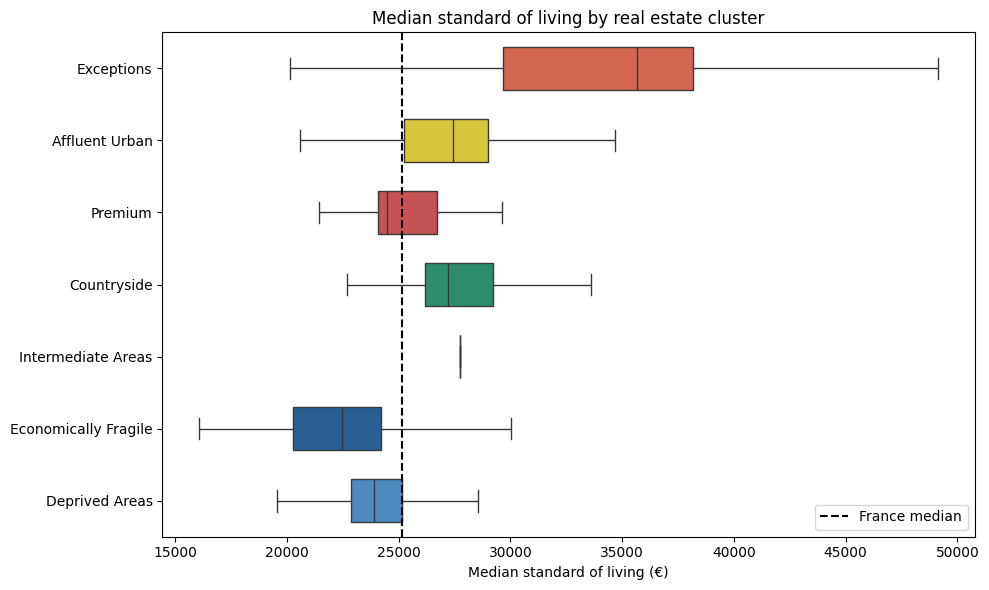

In [40]:
plt.figure(figsize=(10, 6))

sns.boxplot(
    data=cluster_df[cluster_df["cluster"] != -1],
    x="MED_SL",
    y="cluster_name",
    order=cluster_order,
    hue="cluster_name",
    palette=palette,
    legend=False,
    showfliers=False,
    width=0.6,
)
plt.axvline(
    cluster_df["MED_SL"].median(),
    color="black",
    linestyle="dashed",
    label="France median",
)
plt.title("Median standard of living by real estate cluster")
plt.xlabel("Median standard of living (€)")
plt.ylabel("")
plt.legend()
plt.tight_layout()
plt.show()

France median : 25 140 €

Lower than France median (<) :
- Economically Fragile Areas (~ 22 480 €) (-11%)
- Deprived Areas (~ 23 890 €) (-5%)
- Premium (~ 24 500  €) (-3%)

Greater than France median (>) :
- Countryside (~ 27 190 €) (+8%)
- Affluent Urban Areas (~ 27 430 €) (+9%)
- Intermediate Areas (~ 27 750 €) (+10%)
- Exceptions Areas (~ 35 680 €) (+42%)
- Outliers (~ 25 665 €) (+2%)

## Conclusion

#### Relative Median Difference

| Cluster Profile      | Price/m² | Price | Surface | Unemployment rate | Standard of living |
|----------------------|:--------:|:-----:|:-------:|:-----------------:|:------------------:|
| Deprived Areas       |    -     |   -   |    +    |         -         |         -          |
| Economically Fragile |    -     |  --   |    -    |        ++         |         -          |
| Intermediate Areas   |    +     |   +   |    +    |         +         |         +          |
| Countryside          |    +     |   +   |    +    |         +         |         +          |
| Premium              |    +     |   +   |    -    |         +         |         -          |
| Affluent Urban       |    ++    |  ++   |    -    |         -         |         +          |
| Exceptions           |   +++    |  +++  |    +    |         =         |         ++         |
| Outliers             |    -     |   -   |    +    |         -         |         +          |


*Relative to the overall median:*
- `+` / `-` ≈ ±25%
- `++` / `--` ≈ ±50%
- `+++` / `---` ≈ ±75%

Notes:
1. Deprived Areas show unemployment slightly below the national median. This may reflect that these zones include working-class areas with low-skilled employment rather than structurally unemployed territories, unlike Economically Fragile zones which show a clear unemployment signal (+44%).
2. Premium clusters show slightly below-average income despite high prices. This suggests these zones are driven by price tension (supply scarcity, desirability) rather than by local wealth — unlike Affluent Urban zones where both price and income are above average.

####
**Deprived Areas** : Markets where real estate is cheap and where more surface area is purchased for the same budget. Low-tension territories with a low housing cost.

**Economically Fragile** : The most disadvantaged profile in terms of real estate value. Territories in economic difficulty

**Intermediate** : Closer to market average. Balanced markets with sustained economic activity.

**Countryside** : Rural areas where properties offer more surface area, without reaching the price levels of the most sought-after sectors. (Socio-economically close to the Intermediate cluster)

**Premium** : Strong valuation of the location: we pay more for fewer square meters. Housing in a tense area.

**Affluent Urban** : Attractive urban markets where the scarcity of land drives up prices. Premium locations or sought-after property. High-value real estate market. Affluent urban sectors.

**Exceptions** : Atypical or very high-end markets that do not follow general trends. Highest end of the market. Most prestigious or atypical markets.

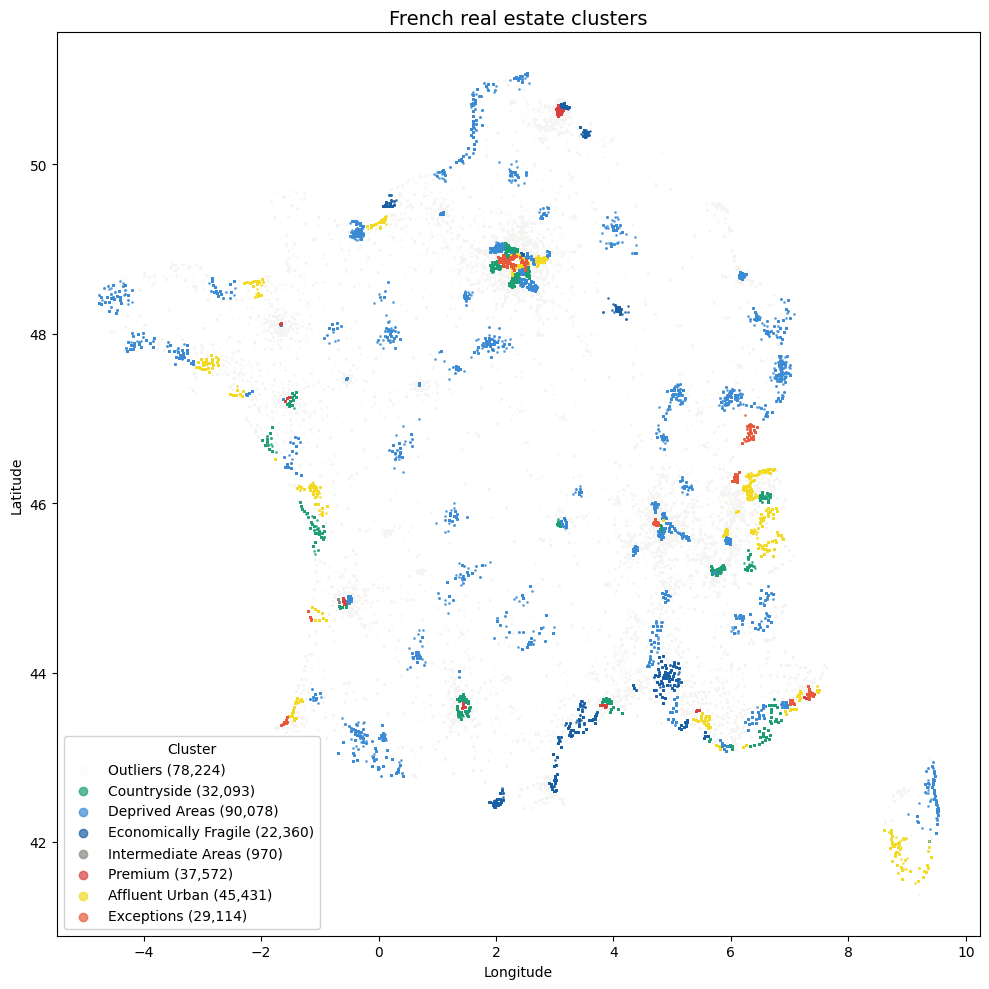

In [41]:
plot_order = [
    "Outliers",
    "Countryside",
    "Deprived Areas",
    "Economically Fragile",
    "Intermediate Areas",
    "Premium",
    "Affluent Urban",
    "Exceptions",
]

fig, ax = plt.subplots(figsize=(10, 10))

for cluster_name in plot_order:
    mask = cluster_df["cluster_name"] == cluster_name
    subset = cluster_df[mask]

    ax.scatter(
        subset["longitude"],
        subset["latitude"],
        c=palette[cluster_name],
        s=1,
        alpha=0.2 if cluster_name == "Outliers" else 0.7,
        label=f"{cluster_name} ({mask.sum():,})",
        rasterized=True,
    )

legend = ax.legend(
    markerscale=6,
    title="Cluster",
    loc="lower left",
    framealpha=0.9,
)

ax.set_title("French real estate clusters", fontsize=14)
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
plt.tight_layout()
plt.show()

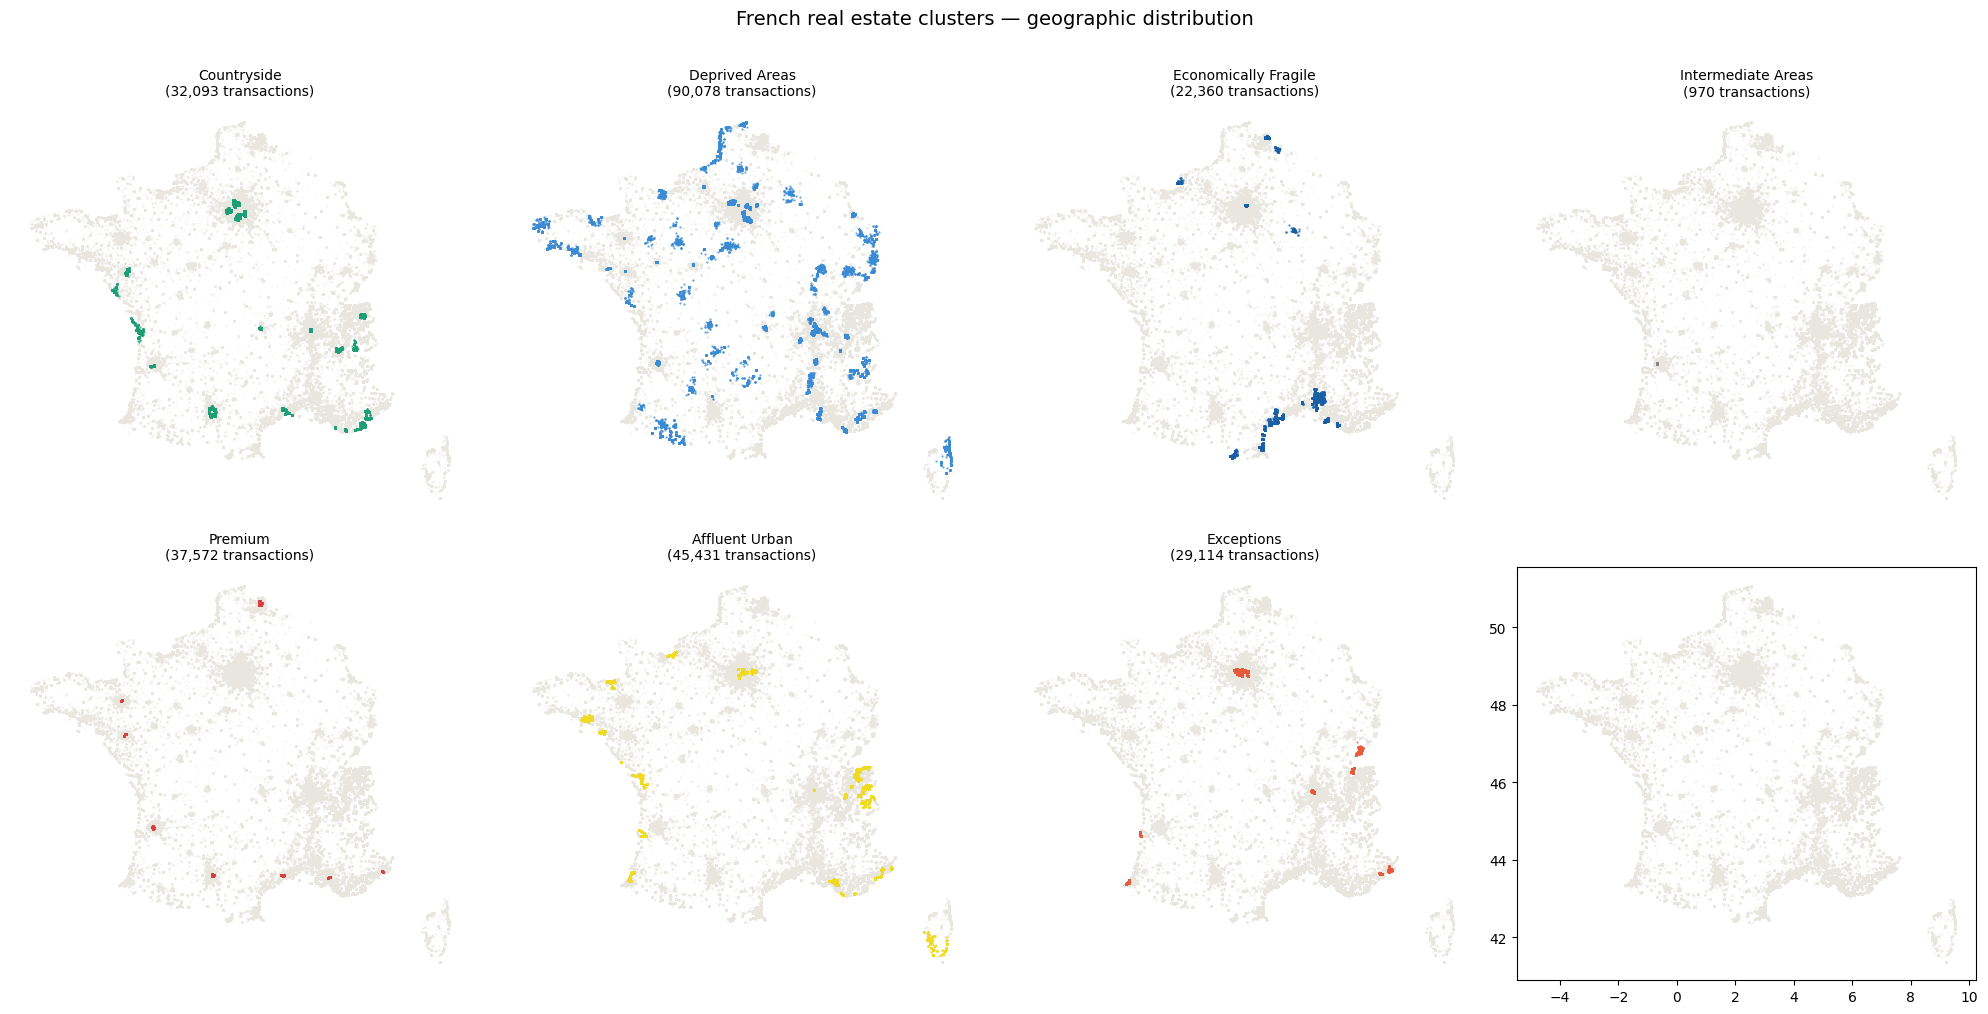

In [49]:
categories = [c for c in plot_order if c != "Outliers"]

fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()

for ax in axes:
    ax.scatter(
        cluster_df["longitude"],
        cluster_df["latitude"],
        c="#E8E6DF",
        s=0.2,
        alpha=0.3,
        rasterized=True,
    )

for ax, cluster_name in zip(axes, categories):
    mask = cluster_df["cluster_name"] == cluster_name
    subset = cluster_df[mask]

    ax.scatter(
        subset["longitude"],
        subset["latitude"],
        c=palette[cluster_name],
        s=0.5,
        alpha=0.6,
        rasterized=True,
    )

    ax.set_title(f"{cluster_name}\n({mask.sum():,} transactions)", fontsize=10)
    ax.set_xlabel("")
    ax.set_ylabel("")
    ax.axis("off")

plt.suptitle("French real estate clusters — geographic distribution", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

**Observations** :
- Deprived Areas : Concentrated in northern France (Nord-Pas-de-Calais), eastern suburbs of major cities, and some Mediterranean areas
- Economically Fragile : Overlaps with former industrial basins (Lorraine, Ardennes, northern suburbs)
- Intermediate : no distinctive characteristic
- Countryside : Periurban ring around all major cities, confirms the "rurban" migration pattern
- Premium : City centres of all major French cities except Paris (captured by Exceptions)
- Affluent Urban : Western suburbs of Paris (92), Lyon west and Bordeaux Métropole, confirms the "bourgeois suburb" pattern
- Exceptions : Paris + Côte d'Azur + Geneva border (franco-swiss market) + Arcachon Bay + Basque Coast (Bayonne/Biarritz) : markets driven by external demand (tourism, expats, finance)

#### Quadrant : Price/m² vs Standard of living

In [43]:
scatter_data = (
    cluster_df[cluster_df["cluster"] != -1]
    .groupby(["longitude", "latitude"])
    .agg(
        prix_m2=("prix_m2", "median"),
        MED_SL=("MED_SL", "median"),
        cluster_name=("cluster_name", lambda x: x.mode()[0]),  # cluster majoritaire
        nb_transactions=("prix_m2", "count"),
    )
    .reset_index()
    .dropna(subset=["prix_m2", "MED_SL"])
)

print(f"{len(scatter_data):,} communes")

2,640 communes


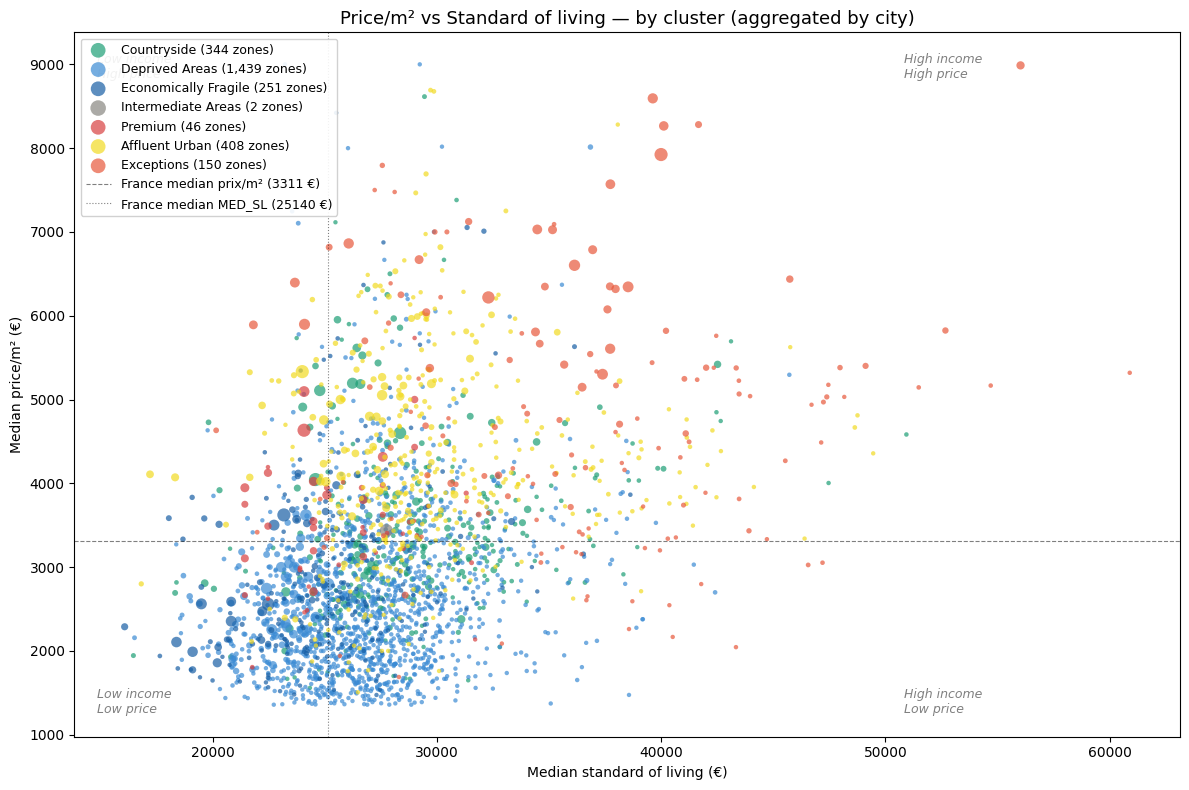

In [52]:
fig, ax = plt.subplots(figsize=(12, 8))

for cluster_name in [c for c in plot_order if c != "Outliers"]:
    mask = scatter_data["cluster_name"] == cluster_name
    subset = scatter_data[mask]

    ax.scatter(
        subset["MED_SL"],
        subset["prix_m2"],
        c=palette[cluster_name],
        s=subset["nb_transactions"] / subset["nb_transactions"].max() * 80 + 10,
        alpha=0.7,
        label=f"{cluster_name} ({mask.sum():,} zones)",
        edgecolors="none",
        rasterized=True,
    )

ax.axhline(
    cluster_df["prix_m2"].median(),
    color="black", linestyle="dashed", linewidth=0.8, alpha=0.5,
    label=f"France median prix/m² ({cluster_df['prix_m2'].median():.0f} €)"
)
ax.axvline(
    cluster_df["MED_SL"].median(),
    color="black", linestyle="dotted", linewidth=0.8, alpha=0.5,
    label=f"France median MED_SL ({cluster_df['MED_SL'].median():.0f} €)"
)

ax.text(0.02, 0.97, "Low income\nHigh price", transform=ax.transAxes, fontsize=9, va="top", color="gray", style="italic")
ax.text(0.75, 0.97, "High income\nHigh price", transform=ax.transAxes, fontsize=9, va="top", color="gray", style="italic")
ax.text(0.02, 0.03, "Low income\nLow price", transform=ax.transAxes, fontsize=9, va="bottom", color="gray", style="italic")
ax.text(0.75, 0.03, "High income\nLow price", transform=ax.transAxes, fontsize=9, va="bottom", color="gray", style="italic")

ax.legend(markerscale=1.5, loc="upper left", fontsize=9, framealpha=0.9)
ax.set_title("Price/m² vs Standard of living — by cluster (aggregated by city)", fontsize=13)
ax.set_xlabel("Median standard of living (€)")
ax.set_ylabel("Median price/m² (€)")
plt.tight_layout()
plt.show()

***Note***: *Each point represents one city coordinates (median aggregation). Point size is proportional to transaction volume. Price axis is capped at the core market ceiling (p90 = ~9,800 €/m²). Premium Parisian arrondissements may appear compressed at the top.*

**Observations** :

A clear positive diagonal gradient confirms that standard of living is a structural driver of real estate prices : the richer the area, the more expensive the properties. However, significant dispersion around the trend suggests that other factors (geography, supply tension, tourism) play an
independent role.

**Quandrant :**

**Bottom left** : Deprived Areas and Economically Fragile dominate this quadrant. These territories combine economic disadvantage with low real estate valuations (a self-reinforcing dynamic where low attractiveness limits both population growth and price appreciation).

**Top right** : Premium and Exceptions concentrate here, confirming that the most
expensive markets are also the wealthiest. However, the two clusters behave differently :
- Exceptions show the highest MED_SL values, wealth-driven markets (Paris, Geneva border, Côte d'Azur)
- Premium clusters appear slightly more to the left. Price is driven by location tension rather than local income alone.

**Top left** : a few isolated points (yellow/red) with a modest standard of living but high prices. These are tension markets: tourist resorts, coastal communes or cities where external demand (second homes, short-term rental) inflates prices independently of local income. This is the most analytically interesting quadrant. It reveals markets where the standard price/income relationship breaks down.

**Bottom right** : almost empty (a high standard of living is almost always accompanied by a high price). This confirms the asymmetry of the relationship : wealth drives prices up, but low prices do not imply low income (Countryside being the exception).

**Cluster positioning**

| Cluster              | Quadrant         | Interpretation                 |
|----------------------|------------------|--------------------------------|
| Exceptions           | Top right        | Wealth + external demand       |
| Premium              | Top center-right | Tension > income               |
| Affluent Urban       | Center right     | Urban wealth, moderate tension |
| Intermediate         | Center           | Market average                 |
| Countryside          | Bottom center    | Rural income, low tension      |
| Deprived Areas       | Bottom left      | Low income, low demand         |
| Economically Fragile | Bottom left      | Structural disadvantage        |

**Key insight**

The bottom-right quadrant being almost empty is the most important structural finding : **in France, high income areas always translate into high real estate prices**.

*The reverse is not true, some low-price areas have decent income levels (Countryside).*

This asymmetry suggests that wealth is a necessary but not sufficient condition for high prices : supply tension, geography, and external demand act as amplifiers.

##### Top-left quadrant - deep dive

High price and modest income zones

In [45]:
median_prix = scatter_data["prix_m2"].median()
median_sl = scatter_data["MED_SL"].median()

top_left = scatter_data[
    (scatter_data["prix_m2"] > median_prix) &
    (scatter_data["MED_SL"] < median_sl)
].sort_values("prix_m2", ascending=False)

top_left = top_left.merge(city_df, on=["longitude", "latitude"], how="left", validate="many_to_one")

In [46]:
top_left_cities = top_left["Commune"].value_counts()
top_left_cities[top_left_cities > 1]

Commune
NANTES                   4
TOULOUSE                 4
AJACCIO                  3
LILLE                    3
MONTPELLIER              3
CERGY                    2
FREJUS                   2
ISTRES                   2
NICE                     2
OULLINS PIERRE BENITE    2
PIERRELAYE               2
RENNES                   2
SAN-GAVINO-DI-CARBINI    2
VILLENEUVE-D'ASCQ        2
Name: count, dtype: int64

| Top left cities       |   Explanation    |
|:----------------------|:----------------:|
| NANTES                |     Big city     |
| TOULOUSE              |     Big city     |
| AJACCIO               |      Corse       |
| LILLE                 |     Big city     |
| MONTPELLIER           |     Big city     |
| CERGY                 |    Near Paris    |
| FREJUS                |   Near Cannes    |
| ISTRES                | Mediterranean Cost |
| NICE                  |     Big city     |
| OULLINS PIERRE BENITE |    Near Lyon     |
| PIERRELAYE            |    Near Paris    |
| RENNES                |     Big city     |
| SAN-GAVINO-DI-CARBINI |      Corse       |
| VILLENEUVE-D'ASCQ     |    Near Lille    |

Two distinct patterns emerge from the top-left quadrant :

**Major French cities with strong housing tension** :
Nantes, Toulouse, Lille, Montpellier, Rennes, Nice

These are fast-growing cities where real estate demand outpaces supply.
Prices are driven by demographic pressure, student population, and economic dynamism (not necessarily by high local income levels).
"Tension market" profile : prices rise faster than wages.

**Tourist and coastal markets** :
Ajaccio, San-Gavino-di-Carbini (Corsica), Fréjus, Istres (Mediterranean coast)

External demand from second-home buyers and seasonal tourism inflates prices independently of local income. Residents face a dual market : local wages but Parisian/tourist-driven prices.

**Paris periurban overspill** :
Cergy, Pierrelaye (Val-d'Oise), Villeneuve-d'Ascq (Lille metropolis), Oullins-Pierre-Bénite (Lyon)

Periurban communes where proximity to a major employment hub drives prices above what local income would suggest. Buyers accept long commutes in exchange for lower prices than the city centre (but prices remain elevated relative to local wages).

**Revised key insight**

The top-left quadrant reveals three mechanisms that decouple prices
from local income:

| Mechanism              | Example cities           | Driver           |
|------------------------|--------------------------|------------------|
| Demographic tension    | Nantes, Toulouse, Rennes | Supply < demand  |
| Tourism / second homes | Ajaccio, Fréjus          | External buyers  |
| Periurban overspill    | Cergy, Pierrelaye        | Proximity to hub |

These findings challenge a purely income-based reading of the market and confirm that **geography, demography, and external demand act as independent price multipliers** : a result consistent with the Random Forest feature importance analysis (latitude/longitude = 20% combined).

### Consistency with Feature Analysis (notebook 04)

| Finding                  | Feature Analysis                       | Clustering                   |
|--------------------------|----------------------------------------|------------------------------|
| Income drives prices     | MED_SL + SL = 42% RF importance        | Top-right quadrant           |
| Geography is independent | Lat/Lon = 20% RF importance            | Top-left quadrant exceptions |
| Tension markets exist    | High dispersion around regression line | Top-left cluster isolation   |

The clustering analysis provides geographic and market-level confirmation
of the statistical relationships identified in the feature importance analysis.

> **French real estate prices are primarily driven by local wealth, amplified by geographic and demographic factors that operate independently of income levels.**